# Final Project
**Members:** Kris Nguyen, Anh Nguyen

# Thesis Statement:
Horror is the most "successful" genre in Hollywood, in other words, it produces the highest Return on Investment (ROI) regardless of critical reviews.

### I. Data Preparation and Preprocessing

Data set source: https://github.com/GettysburgDataScience/datasets/blob/main/movies/imdb_movies.csv

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
# loading data
url = "https://raw.githubusercontent.com/GettysburgDataScience/datasets/main/movies/imdb_movies.csv"
df = pd.read_csv(url)

In [37]:
# data cleaning
df = df.dropna(subset=['budget_x', 'revenue', 'score', 'genre'])
df = df.query('budget_x >= 100000')

df['ROI'] = (df['revenue'] - df['budget_x']) / df['budget_x']

genres = ['Action', 'Comedy', 'Drama', 'Fantasy', 'Horror', 'Mystery', 'Romance', 'Thriller', 'Western']

for genre in genres:
    df[genre] = df['genre'].str.contains(genre)

### II. Figures and Analysis

#### Figure 1: Average ROI by Genre 

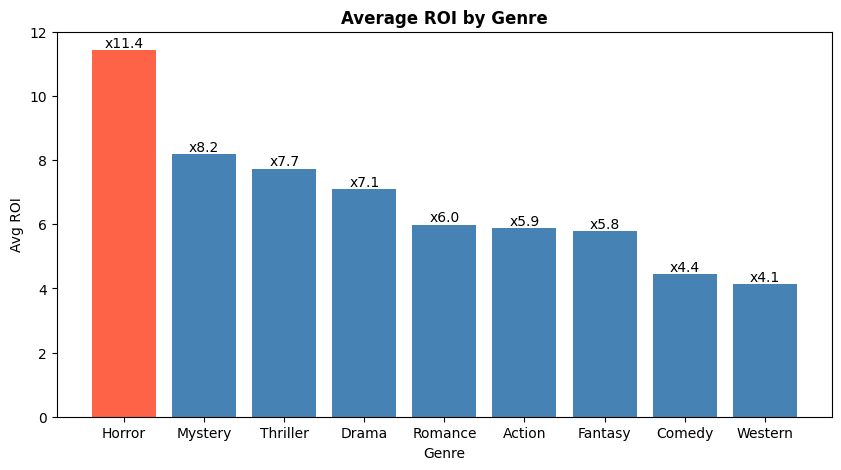

In [ ]:
avg_rois = {}
for g in genres:
    avg_rois[g] = df[df[g]]['ROI'].mean()

avg_rois = dict(sorted(avg_rois.items(), key=lambda x: x[1], reverse=True))

colors = []
for g in avg_rois:
    if g == 'Horror':
        colors.append('tomato')
    else:
        colors.append('steelblue')

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_rois.keys(), avg_rois.values(), color=colors)

plt.title('Average ROI by Genre', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Avg ROI')

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y, f"x{y:.1f}", ha='center', va='bottom')

plt.show()

#### Figure 2: Average production budget

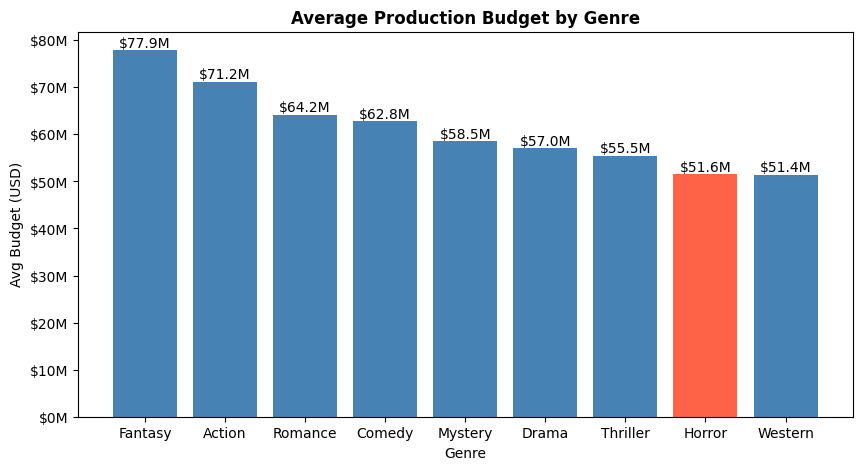

In [57]:
avg_budgets = df[genres].multiply(df['budget_x'], axis=0).sum() / df[genres].sum()
avg_budgets = avg_budgets.sort_values(ascending=False)

colors = ['tomato' if g == 'Horror' else 'steelblue' for g in avg_budgets.index]

from matplotlib.ticker import FuncFormatter
def millions(x, pos):
    return f'${x*1e-6:.0f}M'

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_budgets.index, avg_budgets.values, color=colors)

plt.title('Average Production Budget by Genre', fontweight='bold')
plt.xlabel('Genre')
plt.ylabel('Avg Budget (USD)')
plt.gca().yaxis.set_major_formatter(FuncFormatter(millions))

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, y,
             f'${y*1e-6:.1f}M',
             ha='center', va='bottom')

plt.show()

#### Figure 3: ROI Distributions for Horror Films

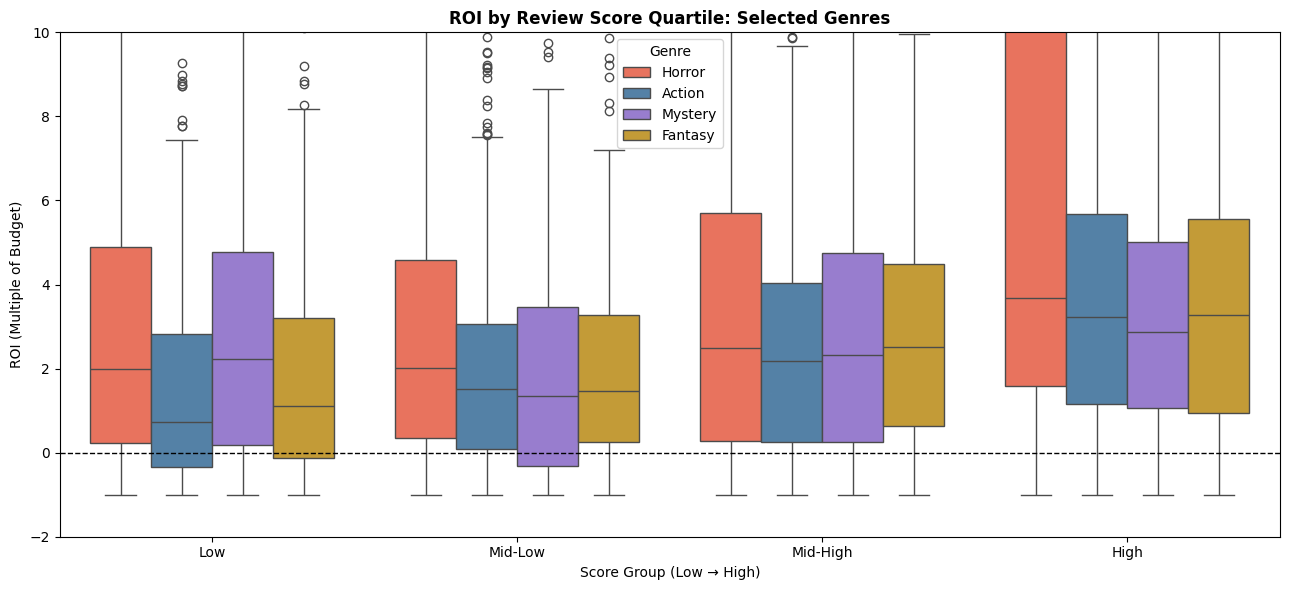

In [66]:
selected_genres = ['Horror', 'Action', 'Mystery', 'Fantasy']

dfs = []
for genre in selected_genres:
    temp = df[df[genre]].copy()
    temp['Genre'] = genre
    dfs.append(temp)

combined = pd.concat(dfs)

combined['score_group'] = pd.qcut(
    combined['score'], 4,
    labels=['Low', 'Mid-Low', 'Mid-High', 'High']
)

plt.figure(figsize=(13, 6))
sns.boxplot(
    x='score_group', y='ROI',
    hue='Genre',
    data=combined,
    palette={'Horror': 'tomato', 'Action': 'steelblue',
             'Mystery': 'mediumpurple', 'Fantasy': 'goldenrod'}
)

plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.ylim(-2, 10)
plt.title('ROI by Review Score Quartile: Selected Genres', fontweight='bold')
plt.xlabel('Score Group (Low → High)')
plt.ylabel('ROI (Multiple of Budget)')
plt.legend(title='Genre')
plt.tight_layout()
plt.show()